In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/email-spam-detection-dataset-classification/spam.csv


# Lets explore the data

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM

2025-04-10 14:40:41.769846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744296042.168266      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744296042.285705      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
df = pd.read_csv('/kaggle/input/email-spam-detection-dataset-classification/spam.csv', encoding='latin1')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.head(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


In [6]:
df1 = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df1.head(3)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [7]:
df1.v1.value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

# Converting to Vectors

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df1['v2'])  # assuming 'message' column
y = df1['v1'].map({'ham': 0, 'spam': 1})  # converting labels to binary


# Random Forest Classifier

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.82      0.90       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



# XGBClassifier

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight= len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
                    use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.94      0.89      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



# LGBMClassifier

In [11]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM Report:\n", classification_report(y_test, y_pred_lgbm))


[LightGBM] [Info] Number of positive: 597, number of negative: 3860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13201
[LightGBM] [Info] Number of data points in the train set: 4457, number of used features: 469
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.95      0.88      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



# RNN

In [12]:
tokens = Tokenizer()
tokens.fit_on_texts(df['v2'])

In [13]:
tokens.word_index

{'i': 1,
 'to': 2,
 'you': 3,
 'a': 4,
 'the': 5,
 'u': 6,
 'and': 7,
 'in': 8,
 'is': 9,
 'me': 10,
 'my': 11,
 'for': 12,
 'your': 13,
 'it': 14,
 'of': 15,
 'call': 16,
 'have': 17,
 'on': 18,
 '2': 19,
 'that': 20,
 'now': 21,
 'are': 22,
 'so': 23,
 'but': 24,
 'not': 25,
 'or': 26,
 'do': 27,
 'can': 28,
 'at': 29,
 "i'm": 30,
 'get': 31,
 'be': 32,
 'will': 33,
 'if': 34,
 'ur': 35,
 'with': 36,
 'just': 37,
 'no': 38,
 'we': 39,
 'this': 40,
 'gt': 41,
 '4': 42,
 'lt': 43,
 'up': 44,
 'when': 45,
 'ok': 46,
 'free': 47,
 'from': 48,
 'how': 49,
 'go': 50,
 'all': 51,
 'out': 52,
 'what': 53,
 'know': 54,
 'like': 55,
 'good': 56,
 'then': 57,
 'got': 58,
 'was': 59,
 'come': 60,
 'its': 61,
 'am': 62,
 'time': 63,
 'only': 64,
 'day': 65,
 'love': 66,
 'there': 67,
 'send': 68,
 'he': 69,
 'want': 70,
 'text': 71,
 'as': 72,
 'txt': 73,
 'one': 74,
 'going': 75,
 'by': 76,
 'home': 77,
 "i'll": 78,
 'need': 79,
 'about': 80,
 'r': 81,
 'lor': 82,
 'sorry': 83,
 'stop': 84,
 'st

In [14]:
sequences = tokens.texts_to_sequences(df['v2'])

max_seq_len = max(len(seq) for seq in sequences)

print(f'Max Sequence length is: {max_seq_len}')

Max Sequence length is: 189


In [15]:
X = pad_sequences(sequences, max_seq_len, padding='pre')
y = df1['v1'].values

In [16]:
X

array([[   0,    0,    0, ...,   58, 4411,  144],
       [   0,    0,    0, ...,  470,    6, 1929],
       [   0,    0,    0, ...,  659,  389, 2988],
       ...,
       [   0,    0,    0, ...,  105,  250, 8919],
       [   0,    0,    0, ...,  200,   12,   47],
       [   0,    0,    0, ...,    2,   61,  268]], dtype=int32)

In [17]:
y = df1['v1'].map({'ham': 0, 'spam': 1})

In [18]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: v1, Length: 5572, dtype: int64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
vocab_size = len(tokens.word_index) + 1
vocab_size

8921

In [21]:
embedding_dim = 100

RNN = Sequential([
    Embedding(vocab_size, embedding_dim, input_length = max_seq_len),
    SimpleRNN(128),
    Dense(1, activation='sigmoid')
])
RNN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1744296072.642173      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1744296072.642909      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [22]:
from sklearn.utils import class_weight


class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y),
                                                  y=y)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict) 

{0: 0.5774093264248704, 1: 3.7295850066934406}


In [23]:
RNN.fit(X_train, y_train, batch_size=150, epochs=50, validation_split=0.2)

Epoch 1/50


I0000 00:00:1744296075.331987      68 service.cc:148] XLA service 0x78871c007b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744296075.333126      68 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1744296075.333149      68 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1744296075.907414      68 cuda_dnn.cc:529] Loaded cuDNN version 90300


 5/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6439 - loss: 0.5844

I0000 00:00:1744296077.528454      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.7885 - loss: 0.4547 - val_accuracy: 0.8655 - val_loss: 0.3166
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9455 - loss: 0.1866 - val_accuracy: 0.9709 - val_loss: 0.0907
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9839 - loss: 0.0588 - val_accuracy: 0.9787 - val_loss: 0.0690
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9946 - loss: 0.0230 - val_accuracy: 0.9888 - val_loss: 0.0522
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9954 - loss: 0.0157 - val_accuracy: 0.9832 - val_loss: 0.0609
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9986 - loss: 0.0083 - val_accuracy: 0.9821 - val_loss: 0.0716
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9888 - val_loss: 0.0564
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9843 - val_loss: 0

In [24]:
RNN.evaluate(X_test, y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9792 - loss: 0.1011


[0.13658742606639862, 0.9793722033500671]

In [25]:
y_pred_prob = RNN.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [26]:
from sklearn.metrics import confusion_matrix,classification_report

In [27]:
confusion_matrix(y_test,y_pred)

array([[964,   1],
       [ 22, 128]])

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.979372197309417

In [29]:
print("RNN Report:\n", classification_report(y_test, y_pred))

RNN Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



# Comparison of Model Classifiers (Precision, Recall, F1-Score)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


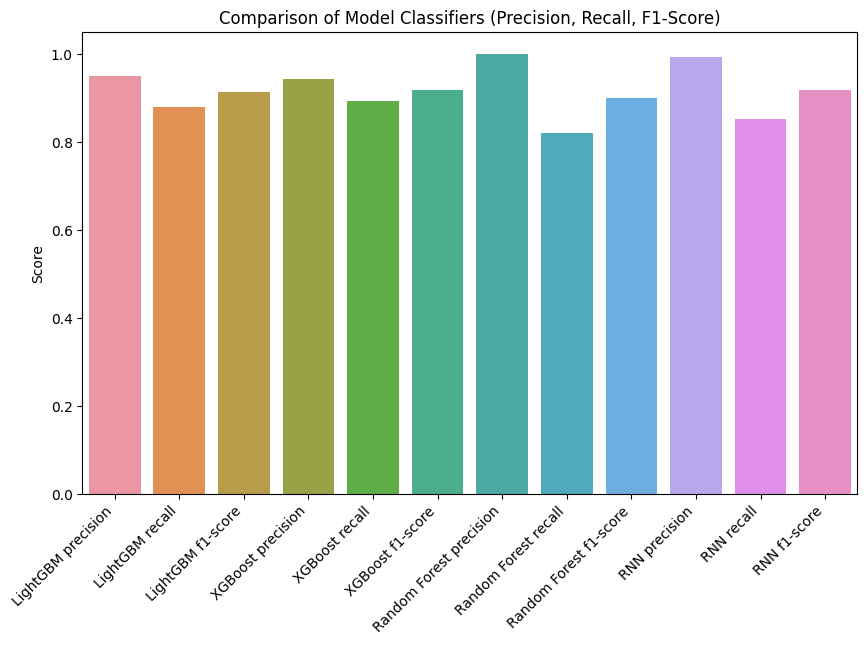

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

report_lgbm = classification_report(y_test, y_pred_lgbm, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_rnn = classification_report(y_test, y_pred, output_dict=True)

# Extract precision, recall, and F1-score for each model
metrics = ['precision', 'recall', 'f1-score']
models = ['LightGBM', 'XGBoost', 'Random Forest', 'RNN']

# Prepare a DataFrame for plotting
metrics_data = {}

for model, report in zip(models, [report_lgbm, report_xgb, report_rf, report_rnn]):
    for metric in metrics:
        metrics_data[f'{model} {metric}'] = [report['1'][metric]]  # Get the score for 'spam' class (1)

# Create a bar plot
labels = [f'{model} {metric}' for model in models for metric in metrics]
values = [score[0] for score in metrics_data.values()]

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Comparison of Model Classifiers (Precision, Recall, F1-Score)')
plt.show()

# Conclusion
The F1 score of Random Forest is 90, XGBoost is 92, LightGBM is 91, and RNN is 91. This means XGBoost performs the best among the models. However, all the models are performing quite well, with only a slight difference in their F1 scores